In [1]:
import sys
sys.path.insert(0, '../lib')

import pandas as pd
import pandas
import numpy as np

import common_data
import common_plots
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import random
import scipy

from sklearn import preprocessing as sk_preprocessing
from statsmodels.stats.multitest import multipletests

In [2]:
common_plots.setup_plotting()

In [3]:
%config InlineBackend.figure_format = "retina"

In [4]:
pd.options.display.max_columns = 200

In [5]:
NB_OF_CLUSTERS = 13

RANDOM_SEED = 42

In [6]:
labels = common_data.get_sc_categorical_covariates()
numericals = common_data.get_sc_numerical_covariates()

In [7]:
categorical_features = labels.columns

In [8]:
l_df = pd.read_csv(common_data.CLINICAL_LABELS, index_col=0)

In [9]:
clinical_data = pd.read_csv(common_data.CLINICAL, index_col=0)

In [10]:
labels['bal_barcode'] = labels.index
labels = labels.set_index('bal_barcode')
numericals['bal_barcode'] = numericals.index
numericals = numericals.set_index('bal_barcode')

In [11]:
flow_cluster_data = pd.read_csv(common_data.FLOW)

In [12]:
BAL_BARCODE_COLNAME = 'bal_barcode'
NEUTROPHIL_COLNAME = 'Neutrophils percent'
NEUTROPHIL_NORMALIZED_POSTFIX = '_NN'
cell_columns = [
    'CD4 T cells percent',
    'CD8 T cells percent',
    'Treg cells percent',
    'CD206high macs percent',
    'CD206low macs percent',
    'Monocytes percent',
    'Neutrophils percent',
]

In [13]:
full_df = flow_cluster_data[
    cell_columns
    + ['bal_barcode', 'Neutrophil Cluster', 'clusters_final']
].merge(
    clinical_data.loc[:, ~clinical_data.columns.isin(cell_columns)],
    on='bal_barcode',
    how='left'
).merge(
    l_df[['bal_barcode'] + l_df.columns[~l_df.columns.isin(clinical_data.columns)].tolist()],
    on='bal_barcode',
    how='left'
)

In [14]:
full_df = full_df.rename(columns=common_data.renames)

In [15]:
full_df = full_df.rename(columns={'Gender': 'Sex'})

Now, here the `Pathogen_groups` and other categorical columns come from single-cell labels, but we have data for all flow. So we join this data from clinical df, and rename the column

In [16]:
full_df.Pathogen_groups.value_counts(dropna=False)

discard                               346
Gram-*                                 83
Early SARS-CoV-2                       70
NPC                                    62
Gram+                                  56
Late SARS-CoV-2                        55
Late SARS-CoV-2; Gram+                 34
Gram-*; Gram+                          30
Pseudomonas aeruginosa                 27
Early SARS-CoV-2; Gram+                20
Pseudomonas aeruginosa; SARS-CoV-2     10
Name: Pathogen_groups, dtype: int64

In [17]:
cluster_scores = np.array([
    int(row_['Flow_clusters']) * 10# + row_['Neutrophil Cluster']
    for _, row_ in full_df.iterrows()
])

In [18]:
cluster_sorting = cluster_scores.argsort()

In [19]:
full_df['Flow_clusters'][cluster_sorting]

645    0
706    0
705    0
418    0
416    0
      ..
328    8
147    8
325    8
125    8
109    8
Name: Flow_clusters, Length: 793, dtype: int64

In [20]:
col_names = [''] * len(cluster_sorting)

for ind_ in range(NB_OF_CLUSTERS):
    selector = full_df['Flow_clusters'][cluster_sorting].to_numpy() == ind_
    start_index = None
    for start_ in range(len(selector)):
        if selector[start_]:
            start_index = start_
            break
    end_index = start_index
    if start_index is None:
        break

    for end_ in range(start_index + 1, len(selector)):
        if selector[end_]:
            end_index = end_
    print(start_index, end_index, ind_)
    cluster_name_ind = int((start_index + end_index) / 2.0)
    col_names[cluster_name_ind] = str(ind_)
    if start_index > 0:
        col_names[start_index] = '|'
    #col_names[end_index] = '|'

0 224 0
225 366 1
367 447 2
448 475 3
476 517 4
518 596 5
597 650 6
651 721 7
722 792 8


In [23]:
scaler = sk_preprocessing.StandardScaler()
flow_data_nn = (full_df[cell_columns]).copy() ** 0.5
flow_data_nn[cell_columns] = scaler.fit_transform(flow_data_nn)

In [24]:
full_df['Flow_clusters'].max()

8

In [25]:
col_colors = full_df.Pathogen_groups.replace({
    'NPC': '#256b33',
    'Early SARS-CoV-2': '#18b3e2',
    'Late SARS-CoV-2': '#2188a8',
    'Early SARS-CoV-2; Gram+': '#cc43f2',
    'Late SARS-CoV-2; Gram+': '#9621b7',
    'discard': '#cfcfcf',
    'Pseudomonas aeruginosa; SARS-CoV-2': '#8f56bf',
    'Gram+': '#ef7267',
    'Pseudomonas aeruginosa': '#d83122',
    'Gram-*; Gram+': '#af3407',
    'Gram-*': '#c15a34'
}).to_frame()

In [26]:
cell_columns

['CD4 T cells percent',
 'CD8 T cells percent',
 'Treg cells percent',
 'CD206high macs percent',
 'CD206low macs percent',
 'Monocytes percent',
 'Neutrophils percent']

In [27]:
cell_columns_pretty_names = [
    'CD4$^{+}$ T cells',
    'CD8$^{+}$ T cells',
    'T$_{\\text{reg}}$ cells',
    'CD206$^{\\text{hi}}$ macrophages',
    'CD206$^{\\text{lo}}$ macrophages',
    'Monocytes',
    'Neutrophils'
]

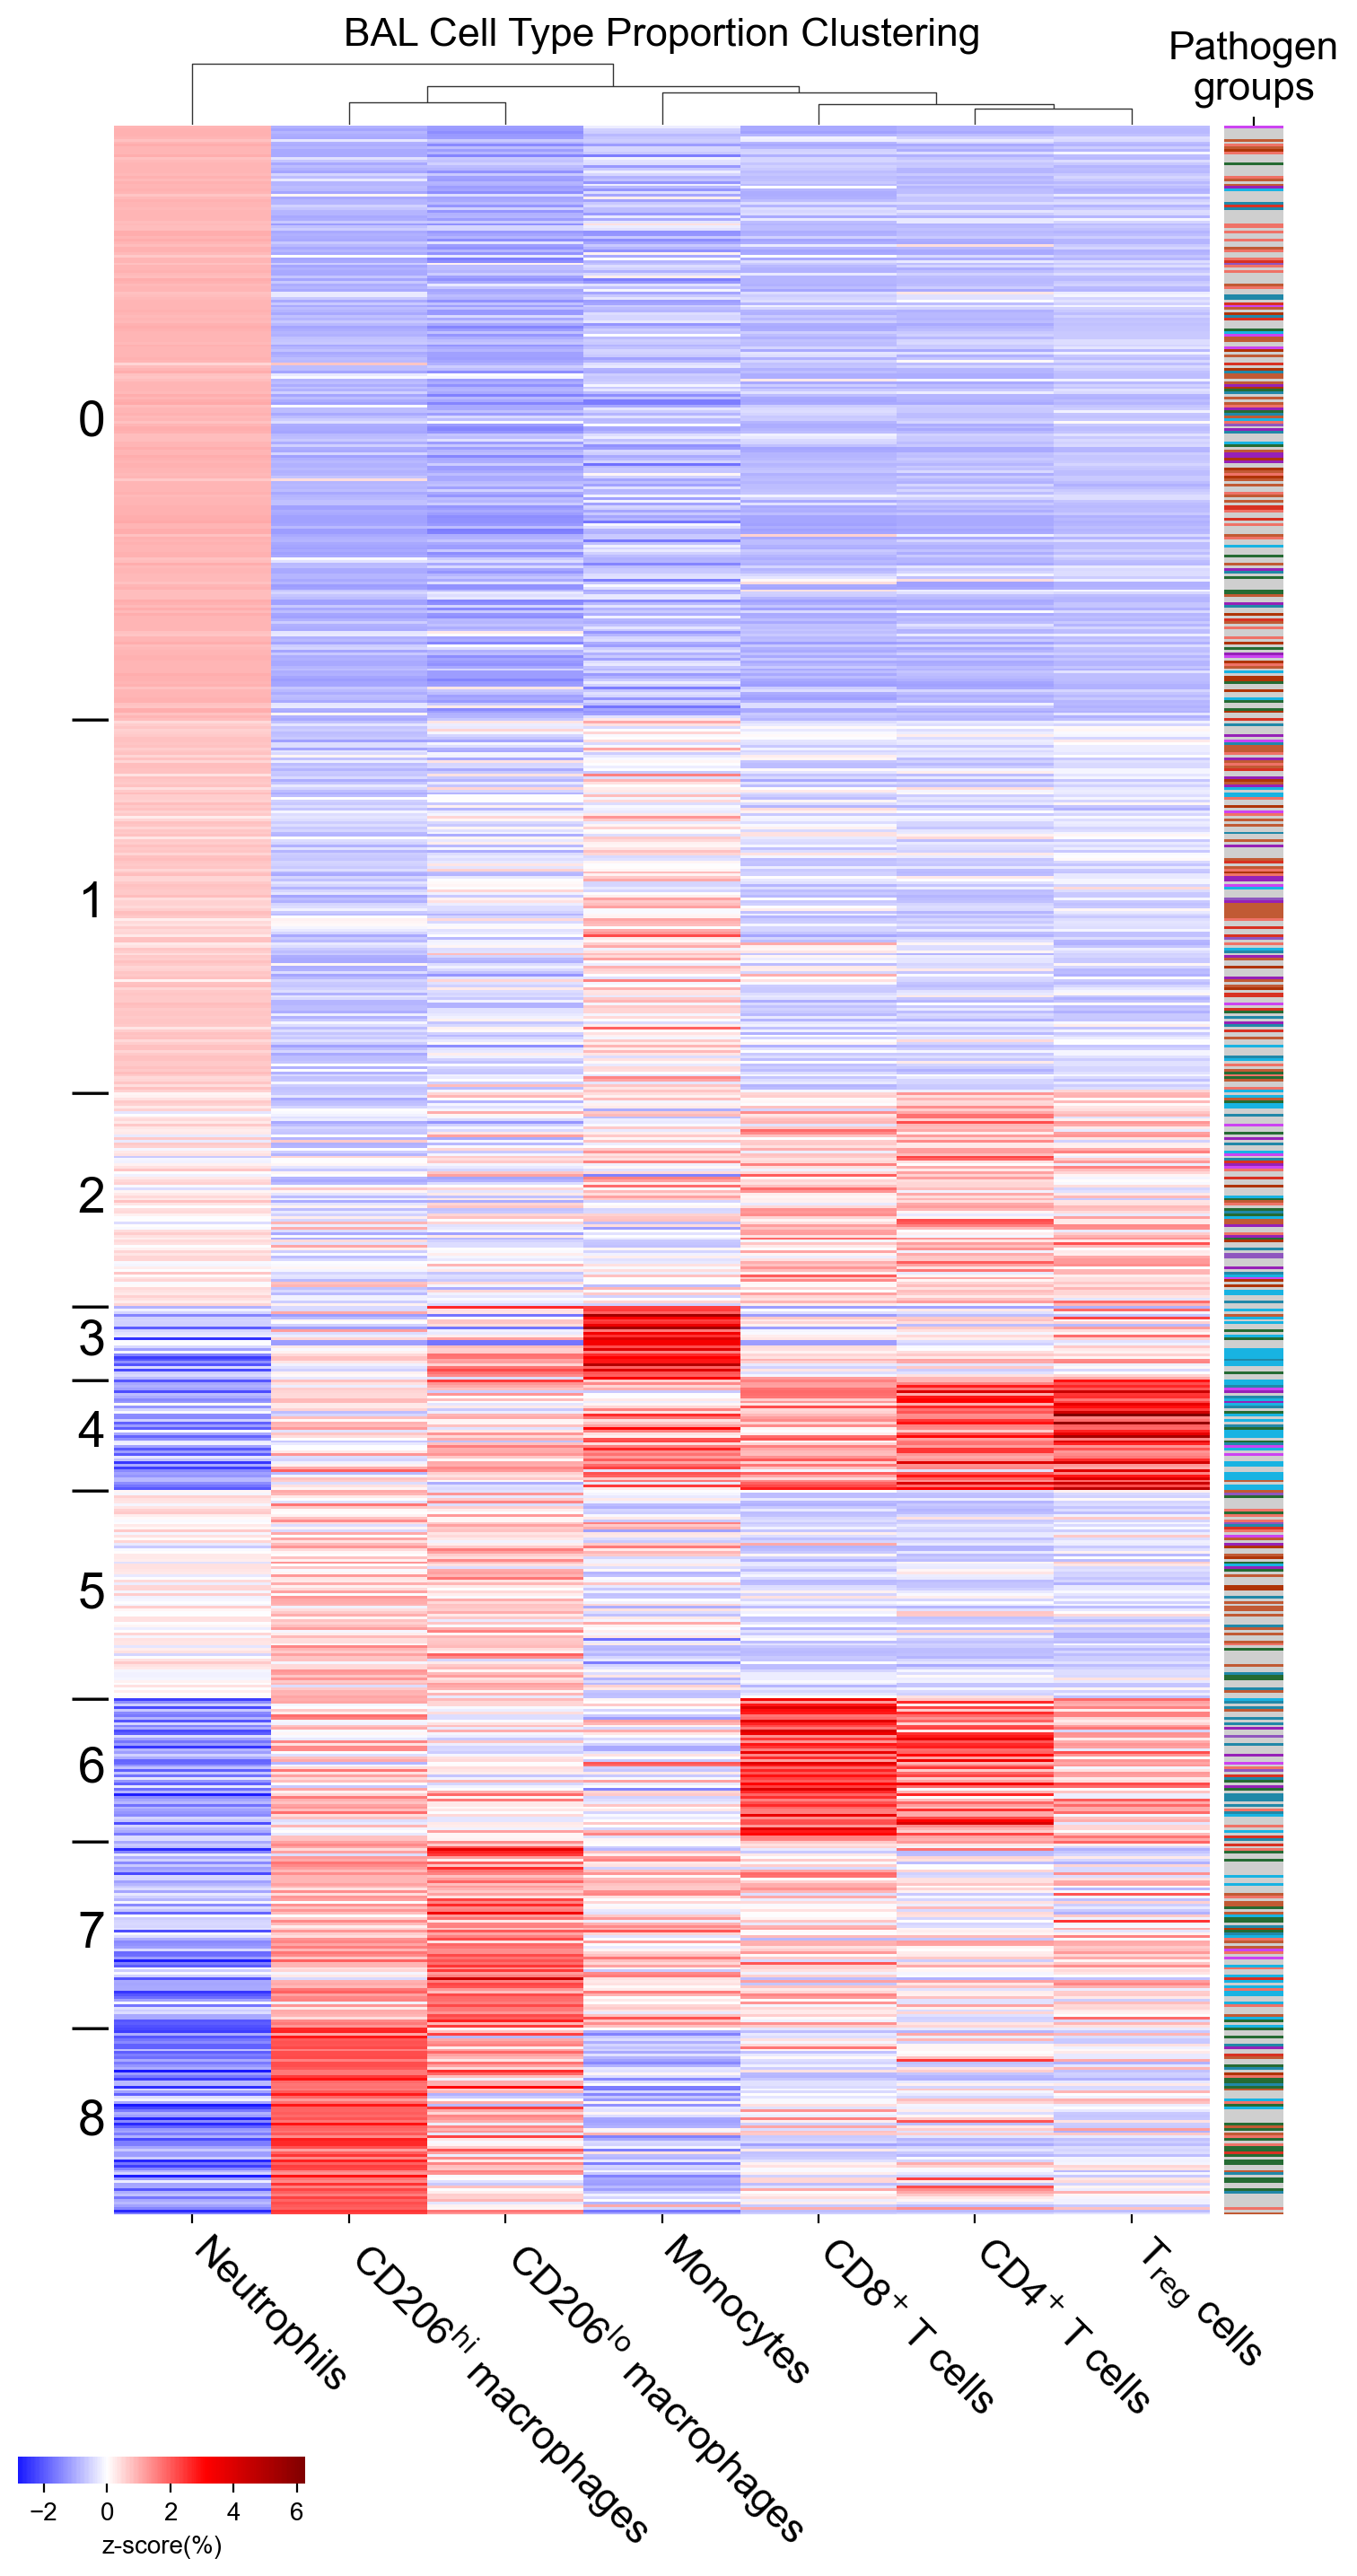

In [28]:
clustermap = sns.clustermap(
    flow_data_nn[cell_columns].loc[cluster_sorting],
    z_score=1,
    method='complete',
    metric='cityblock',
    cmap='seismic',
    row_cluster=False,
    figsize=(8, 15),
    colors_ratio=0.05,
    dendrogram_ratio=0.03,
    center=0,
    yticklabels=col_names,
    xticklabels=cell_columns_pretty_names,
    row_colors=col_colors,
    cbar_pos=(0, 0.02, 0.2, 0.01),
    cbar_kws=dict(
        label='z-score(%)',
        orientation='horizontal',
        ticks=[-2, 0, 2, 4, 6]
    ),
)

clustermap.ax_row_dendrogram.set_visible(False)
_ = clustermap.ax_col_dendrogram.set_title('BAL Cell Type Proportion Clustering', fontsize=16)
clustermap.ax_heatmap.set_yticklabels(clustermap.ax_heatmap.get_ymajorticklabels(), fontsize=16)
clustermap.ax_heatmap.set_xticklabels(
    clustermap.ax_heatmap.get_xmajorticklabels(),
    fontsize=16,
    rotation=315,
    ha='left'
)
trans = mpl.transforms.Affine2D().translate(-8, 0)
for t in clustermap.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

clustermap.ax_heatmap.tick_params(
    axis='y',
    size=0,
    left=True,
    right=False,
    labelleft=True,
    labelright=False
)
clustermap.ax_row_colors.tick_params(
    axis='x',
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
)
clustermap.ax_row_colors.set_xticklabels(['Pathogen\ngroups'], size=16)

for t in clustermap.ax_heatmap.get_yticklabels():
    t.set_va('bottom')
    if t.get_text() != '' and t.get_text() != '|':
        t.set_rotation(0)
        t.set_size(20)
        t.set_va('center')

clustermap.fig.subplots_adjust(left=0.05, right=0.88, bottom=0.15, top=0.95)

p = clustermap.ax_row_colors.get_position()
w = p.x1 - p.x0
p_hm = clustermap.ax_heatmap.get_position()
p.x0 = p_hm.x1 + 0.01
p.x1 = p.x0 + w
clustermap.ax_row_colors.set_position(p)

clustermap.cax.set_position((0.05, 0.05, 0.2, 0.01))

clustermap.figure.savefig('10I_flow_clusters.pdf')

In [29]:
coarse_colors = {
    'NPC': '#42c95d',
    'viral': '#4638e2',
    'bacterial': '#c93434',
    'superinfection': '#cca135',
    'discard': 'white'
}

In [30]:
col_colors['Pathogen_groups'] = full_df.Pathogen_groups.replace({
    'NPC': coarse_colors['NPC'],
    'Early SARS-CoV-2': coarse_colors['viral'],
    'Late SARS-CoV-2': coarse_colors['viral'],
    'Early SARS-CoV-2; Gram+': coarse_colors['superinfection'],
    'Late SARS-CoV-2; Gram+': coarse_colors['superinfection'],
    'discard': coarse_colors['discard'],
    'Pseudomonas aeruginosa; SARS-CoV-2': coarse_colors['superinfection'],
    'Gram+': coarse_colors['bacterial'],
    'Pseudomonas aeruginosa': coarse_colors['bacterial'],
    'Gram-*; Gram+': coarse_colors['bacterial'],
    'Gram-*': coarse_colors['bacterial']
})

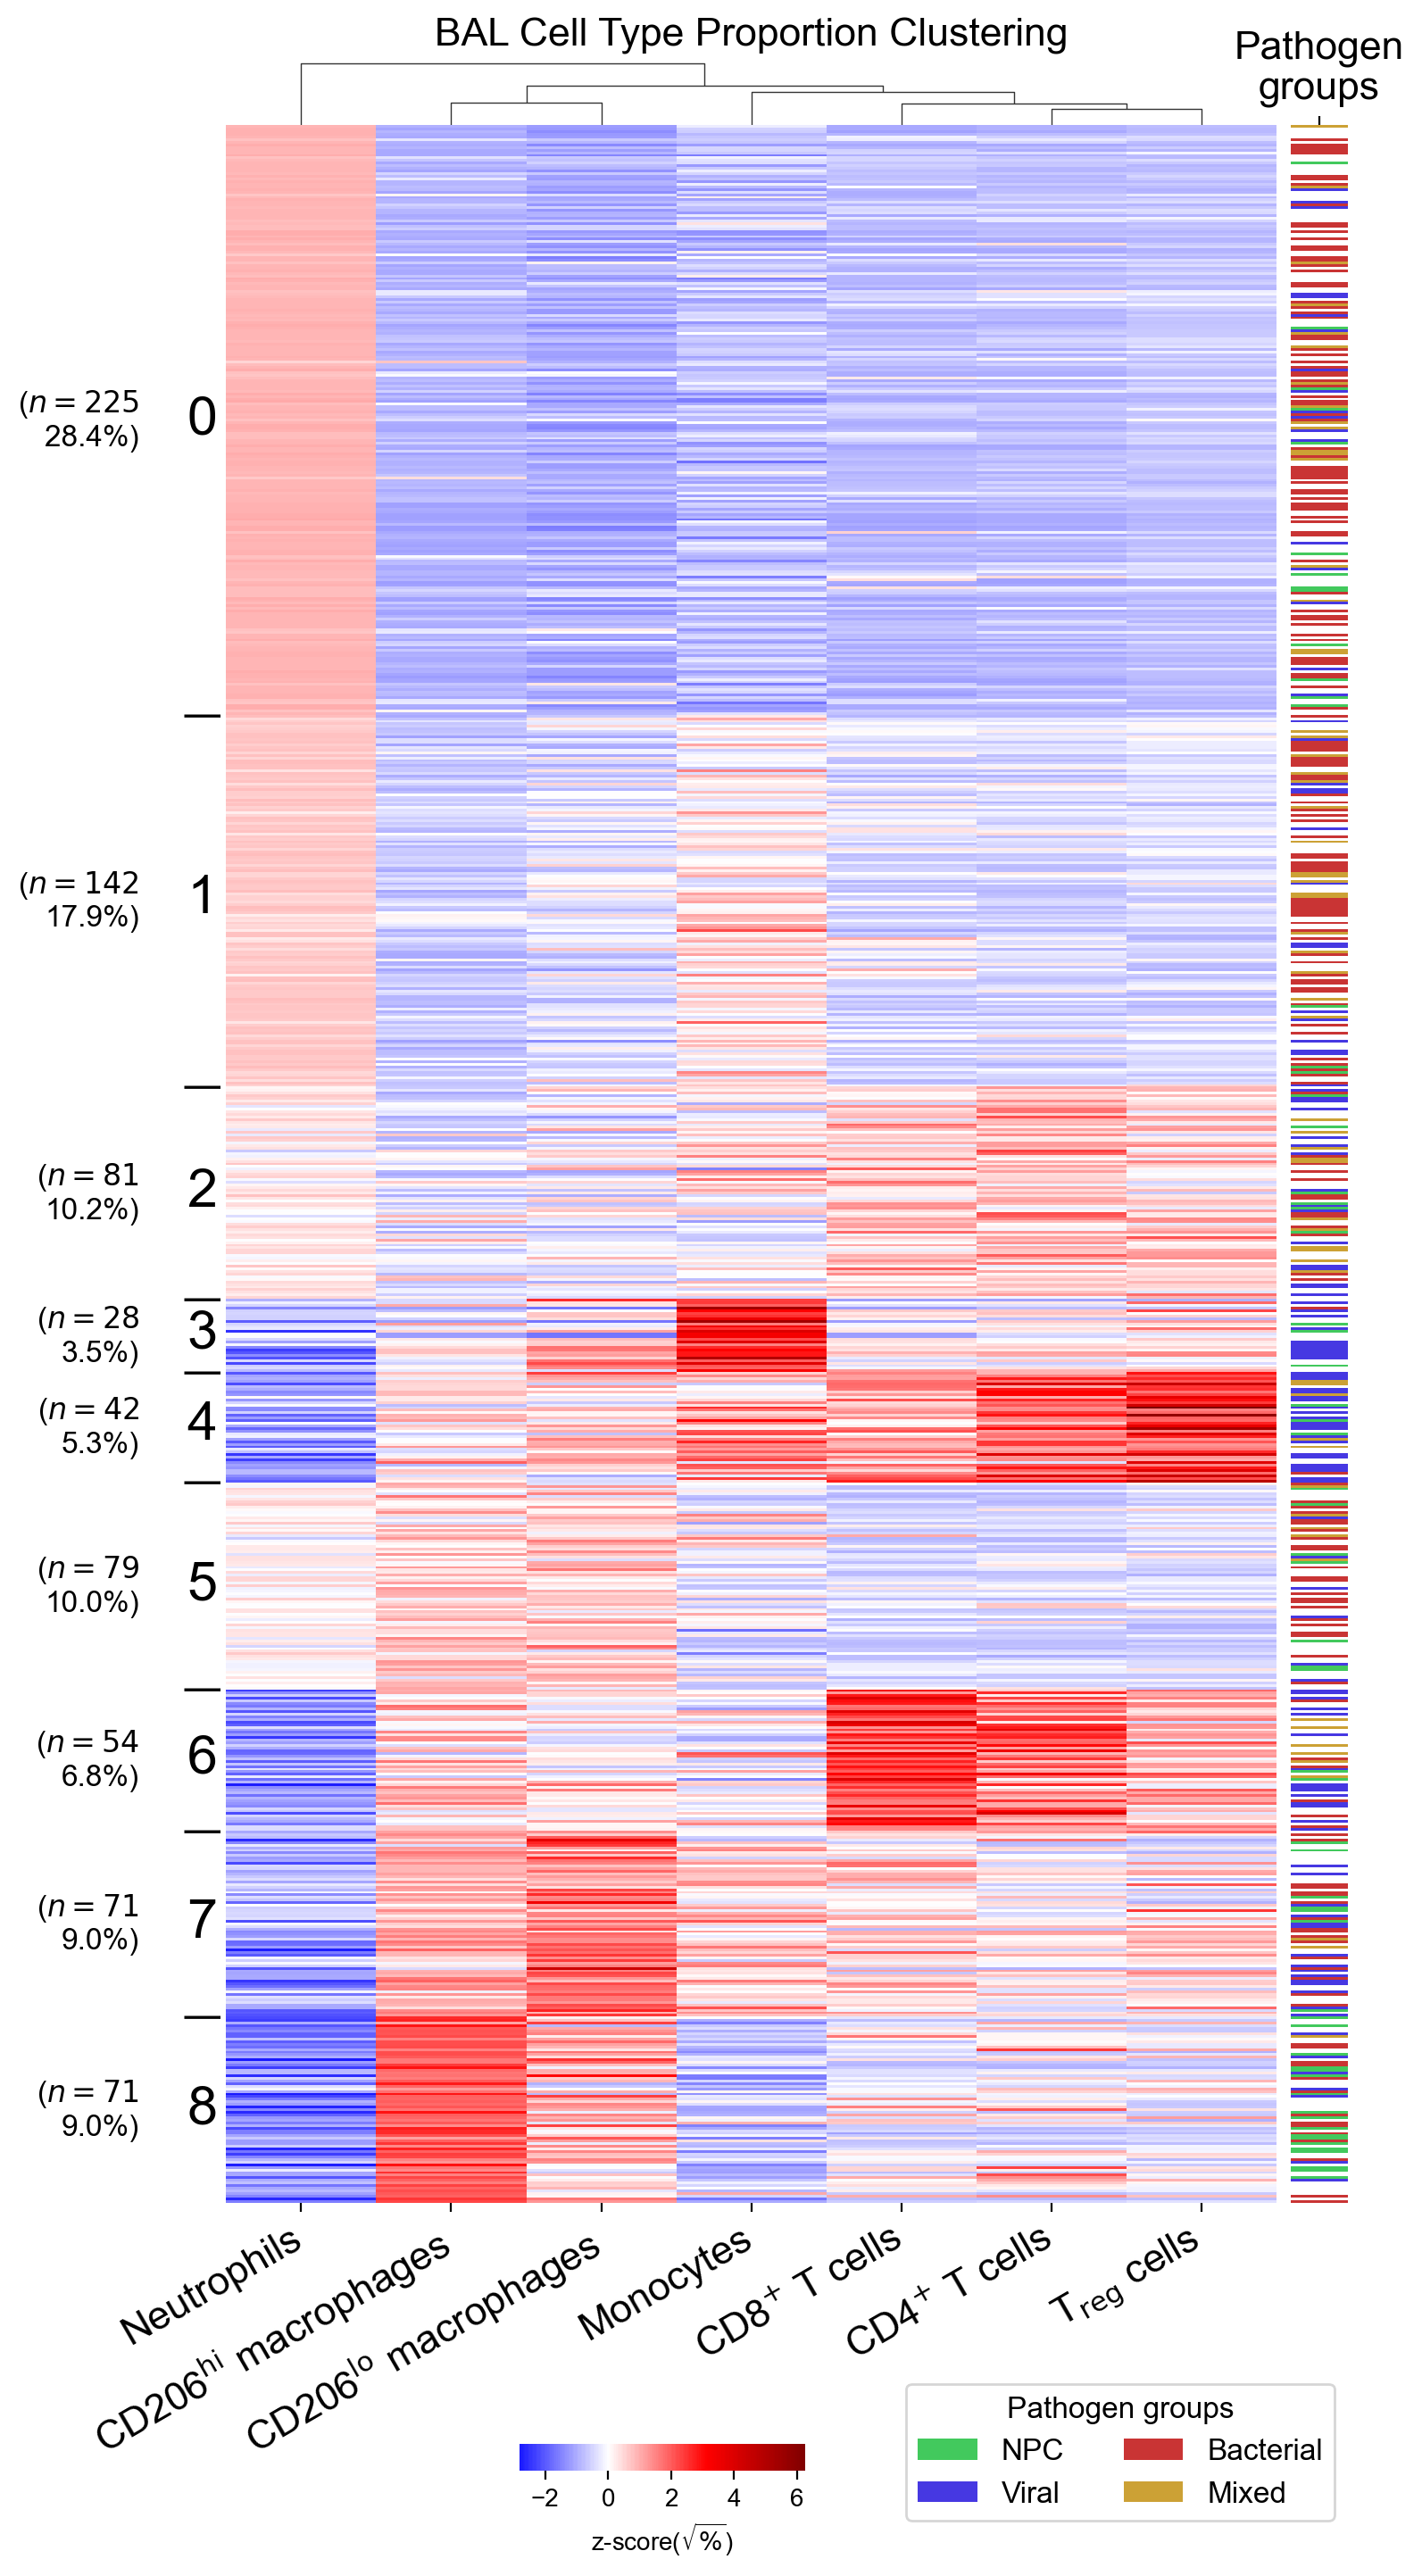

In [33]:
clustermap = sns.clustermap(
    flow_data_nn[cell_columns].loc[cluster_sorting],
    z_score=1,
    method='complete',
    metric='cityblock',
    cmap='seismic',
    row_cluster=False,
    figsize=(8, 15),
    colors_ratio=0.05,
    # row_colors=row_cluster,
    dendrogram_ratio=0.03,
    center=0,
    yticklabels=col_names,
    xticklabels=cell_columns_pretty_names,
    row_colors=col_colors,
    cbar_pos=(0, 0.02, 0.2, 0.01),
    cbar_kws=dict(
        label='z-score($\sqrt{\%}$)',
        orientation='horizontal',
        ticks=[-2, 0, 2, 4, 6]
    ),
)

clustermap.ax_row_dendrogram.set_visible(False)
_ = clustermap.ax_col_dendrogram.set_title('BAL Cell Type Proportion Clustering', fontsize=16)
clustermap.ax_heatmap.set_yticklabels(clustermap.ax_heatmap.get_ymajorticklabels(), fontsize=16)
clustermap.ax_heatmap.set_xticklabels(
    clustermap.ax_heatmap.get_xmajorticklabels(),
    fontsize=16,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in clustermap.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

clustermap.ax_heatmap.tick_params(
    axis='y',
    size=0,
    left=True,
    right=False,
    labelleft=True,
    labelright=False
)
clustermap.ax_row_colors.tick_params(
    axis='x',
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
)
clustermap.ax_row_colors.set_xticklabels(['Pathogen\ngroups'], size=16)
clustermap.ax_row_colors.legend(
    handles=[
        mpl.patches.Patch(fc=coarse_colors['NPC'], label='NPC'),
        mpl.patches.Patch(fc=coarse_colors['viral'], label='Viral'),
        mpl.patches.Patch(fc=coarse_colors['bacterial'], label='Bacterial'),
        mpl.patches.Patch(fc=coarse_colors['superinfection'], label='Mixed'),
    ],
    ncols=2,
    loc='upper left',
    bbox_to_anchor=(-7, -0.08),
    title='Pathogen groups',
    fontsize=12,
    title_fontsize=12
)

for t in clustermap.ax_heatmap.get_yticklabels():
    t.set_va('bottom')
    if t.get_text() != '' and t.get_text() != '|':
        t.set_rotation(0)
        t.set_size(22)
        t.set_va('center')

i = 0
for cluster in sorted(full_df.Flow_clusters.unique()):
    n_samples = full_df.Flow_clusters.eq(cluster).sum()
    pct_samples = n_samples / full_df.shape[0]
    clustermap.ax_heatmap.annotate(
        f'($n={n_samples}$\n{pct_samples * 100:.1f}%)',
        xy=(0, i + n_samples / 2),
        xytext=(-35, 0),
        xycoords='data',
        textcoords='offset points',
        ha='right',
        va='center',
        fontsize=12
    )
    i += n_samples

clustermap.figure.subplots_adjust(left=0.08, right=0.88, bottom=0.15, top=0.95)

p = clustermap.ax_row_colors.get_position()
w = p.x1 - p.x0
p_hm = clustermap.ax_heatmap.get_position()
p.x0 = p_hm.x1 + 0.01
p.x1 = p.x0 + w
clustermap.ax_row_colors.set_position(p)

clustermap.cax.set_position((0.35, 0.05, 0.2, 0.01))

clustermap.figure.savefig('10I_flow_clusters_coarse.pdf')

In [ ]:
def compute_hypergeometrics_for_df(
    df,
    column,
    values = None,
    cluster_column='Flow_clusters',
    add_prefix=True,
    filter_nas=True,
    filter_clusters=None,
    min_p_value=1e-5,
    min_count=3
):
    filter_clusters = filter_clusters if filter_clusters is not None else []
    nb_of_clusters = len(set(df[cluster_column]))
    clusters = [cl_ for cl_ in range(nb_of_clusters) if cl_ not in filter_clusters]
    if filter_nas:
        df = df.copy()
        df = df[np.logical_not(df[column].isna())]
    if values is None:
        values = []
        for value, count in df[column].value_counts(dropna=False).items():
            if count >= min_count:
                values.append(value)
    results = np.zeros((len(clusters), len(values)))
    for val_nb, val in enumerate(values):
        for cluster_ind, cluster_nb in enumerate(clusters):
            cluster_count = (df[cluster_column] == cluster_nb).sum()
            if cluster_count == 0:
                results[cluster_ind, val_nb] = 1
                continue
            val_count = (df[column] == val).sum()
            val_within_cluster_count = (np.logical_and(df[column] == val, df[cluster_column] == cluster_nb)).sum()
            total = df.shape[0] # Total number of non-na samples
            cdf = scipy.stats.hypergeom.cdf(
                k=val_within_cluster_count - 1,
                M=total,
                n=val_count,
                N=cluster_count
            )
            results[cluster_ind, val_nb] = 1 - cdf
    results = np.maximum(results, min_p_value)
    if add_prefix:
        col_values = [f'{column}: {val}' for val in values]
    else:
        col_values = values
    result_df = pd.DataFrame(data=results, columns=col_values, index=clusters)
    return result_df

In [35]:
compute_hypergeometrics_for_df(
    df=full_df,
    column='VAP_is_cured_d7',
)

,VAP_is_cured_d7: -1,VAP_is_cured_d7: 0,VAP_is_cured_d7: 1
0,0.836269,0.195361,0.487259
1,0.978208,0.201153,0.075762
2,0.975397,0.041244,0.379486
3,0.057462,1.000000,0.885275
4,0.210302,1.000000,0.369329
5,0.452401,0.423878,0.852174
6,0.066467,0.814282,0.985748
7,0.127577,0.982182,0.609565
8,0.222054,0.828230,0.784815


In [36]:
def apply_fdr_to_df(
    df,
    alpha=0.1,
    method='fdr_bh'
):
    pvals = df.to_numpy().copy()
    flatten_pvals = pvals.flatten()
    _, q_vals, _, _ = multipletests(flatten_pvals, method=method, alpha=alpha)
    new_df = pd.DataFrame(data=q_vals.reshape(df.shape), columns=df.columns, index=df.index)
    return new_df

In [ ]:
data_columns = [
    feature for feature in categorical_features
    if feature not in ('Flow_clusters', 'ScRNAseq_clusters', 'Healthy_vs_NPC_vs_Pathogen')
]

In [38]:
categorical_features

Index(['Binary_outcome', 'CRRT_flag', 'Discharge_disposition', 'ECMO_flag',
       'Episode_category', 'Episode_etiology', 'Episode_is_cured', 'Ethnicity',
       'Sex', 'Global_cause_failure', 'Hemodialysis_flag',
       'Immunocompromised_flag', 'Norepinephrine_flag',
       'Pathogen_bacteria_detected', 'Pathogen_fungi_detected',
       'Pathogen_resistance_detected', 'Pathogen_virus_detected', 'Race',
       'Smoking_status', 'Tracheostomy_flag', 'Flow_clusters',
       'ScRNAseq_clusters', 'Pathogen_groups', 'Healthy_vs_NPC_vs_Pathogen',
       'VAP_is_cured_d7', 'VAP_onset_within_7d'],
      dtype='object')

In [39]:
full_df.drop(columns=['Healthy_vs_NPC_vs_Pathogen'], inplace=True)

In [40]:
full_df[full_df[data_columns] == 'NA'] = np.nan
full_df[full_df[data_columns] == '-1'] = np.nan
full_df[full_df[data_columns] == -1] = np.nan
full_df[full_df[data_columns] == 'discard'] = np.nan

In [41]:
full_df['VAP_is_cured_d7'].value_counts(dropna=False)

NaN    673
0.0     62
1.0     58
Name: VAP_is_cured_d7, dtype: int64

In [42]:
full_df = full_df.drop_duplicates(subset='bal_barcode')

In [43]:
all_pvals = [
    compute_hypergeometrics_for_df(
        df=full_df,
        column=data_col,
        filter_clusters=[],
        filter_nas=True,
        min_p_value=1e-10,
        min_count=3
    )
    for data_col in data_columns
]

In [44]:
full_pvals = pd.concat(all_pvals, axis=1)

Drop this because `Pathogen_groups: NPC` is almost equivalent to `Episode_category: NPC`

In [45]:
full_pvals.drop(columns='Pathogen_groups: NPC', inplace=True)

In [46]:
full_qvals = apply_fdr_to_df(full_pvals, alpha=0.05)

In [47]:
significant_cols = []

for col_name, col_min in full_qvals.min(axis=0).items():
    if col_min < 0.05:
        significant_cols.append(col_name)

In [48]:
significant_full_qvals = full_qvals[significant_cols]

In [49]:
def get_stars_from_pvalue(pvalue):
    result = ''
    if pvalue < 0.05:
        result += '*'
    if pvalue < 0.01:
        result += '*'
    if pvalue < 0.001:
        result += '*'
    return result

In [50]:
clustering_sorting_names = [
    '0. Neutrophil+',
    '1. Neutrophil+ Monocyte',
    '2. Neutrophil+ T cell',
    '3. Monocyte+',
    '4. T cell+ Treg',
    '5. Neutrophil+ Macrophage',
    '6. T cell+ CD8',
    '7. Macrophage+',
    '8. Mature macrophage+',
]

Select and curate categories

In [51]:
significant_full_qvals.columns.tolist()

['Binary_outcome: 1',
 'Binary_outcome: 0',
 'CRRT_flag: 1',
 'Discharge_disposition: Died',
 'Discharge_disposition: Home',
 'ECMO_flag: 0',
 'ECMO_flag: 1',
 'Episode_category: VAP',
 'Episode_category: CAP',
 'Episode_category: NPC',
 'Episode_etiology: Bacterial',
 'Episode_etiology: Viral',
 'Episode_etiology: Culture-negative',
 'Pathogen_bacteria_detected: False',
 'Pathogen_bacteria_detected: True',
 'Pathogen_fungi_detected: False',
 'Pathogen_virus_detected: False',
 'Pathogen_virus_detected: True',
 'Tracheostomy_flag: 1',
 'Pathogen_groups: Early SARS-CoV-2',
 'Pathogen_groups: Late SARS-CoV-2']

In [ ]:
to_show = {
    'Episode_etiology: Bacterial': 'Adjudicated pathogen: bacterial',
    'Pathogen_bacteria_detected: True': 'Bacteria detected',
    'Episode_etiology: Culture-negative': 'Adjudicated pathogen: negative',
    'Episode_category: VAP': 'VAP',
    'Pathogen_groups: Early SARS-CoV-2': 'Early SARS-CoV-2',
    'Episode_etiology: Viral': 'Adjudicated pathogen: viral',
    'Pathogen_virus_detected: True': 'Virus detected',
    'Pathogen_groups: Late SARS-CoV-2': 'Late SARS-CoV-2',
    'Episode_category: NPC': 'NPC',
    'Binary_outcome: 0': 'Survived',
    'Discharge_disposition: Home': 'Discharge disposition: Home',
    'ECMO_flag: 1': 'ECMO',
    'Binary_outcome: 1': 'Died',
}

In [53]:
cluster_order = [
    0, 5, 1, 2, 6, 4, 3, 7, 8
]

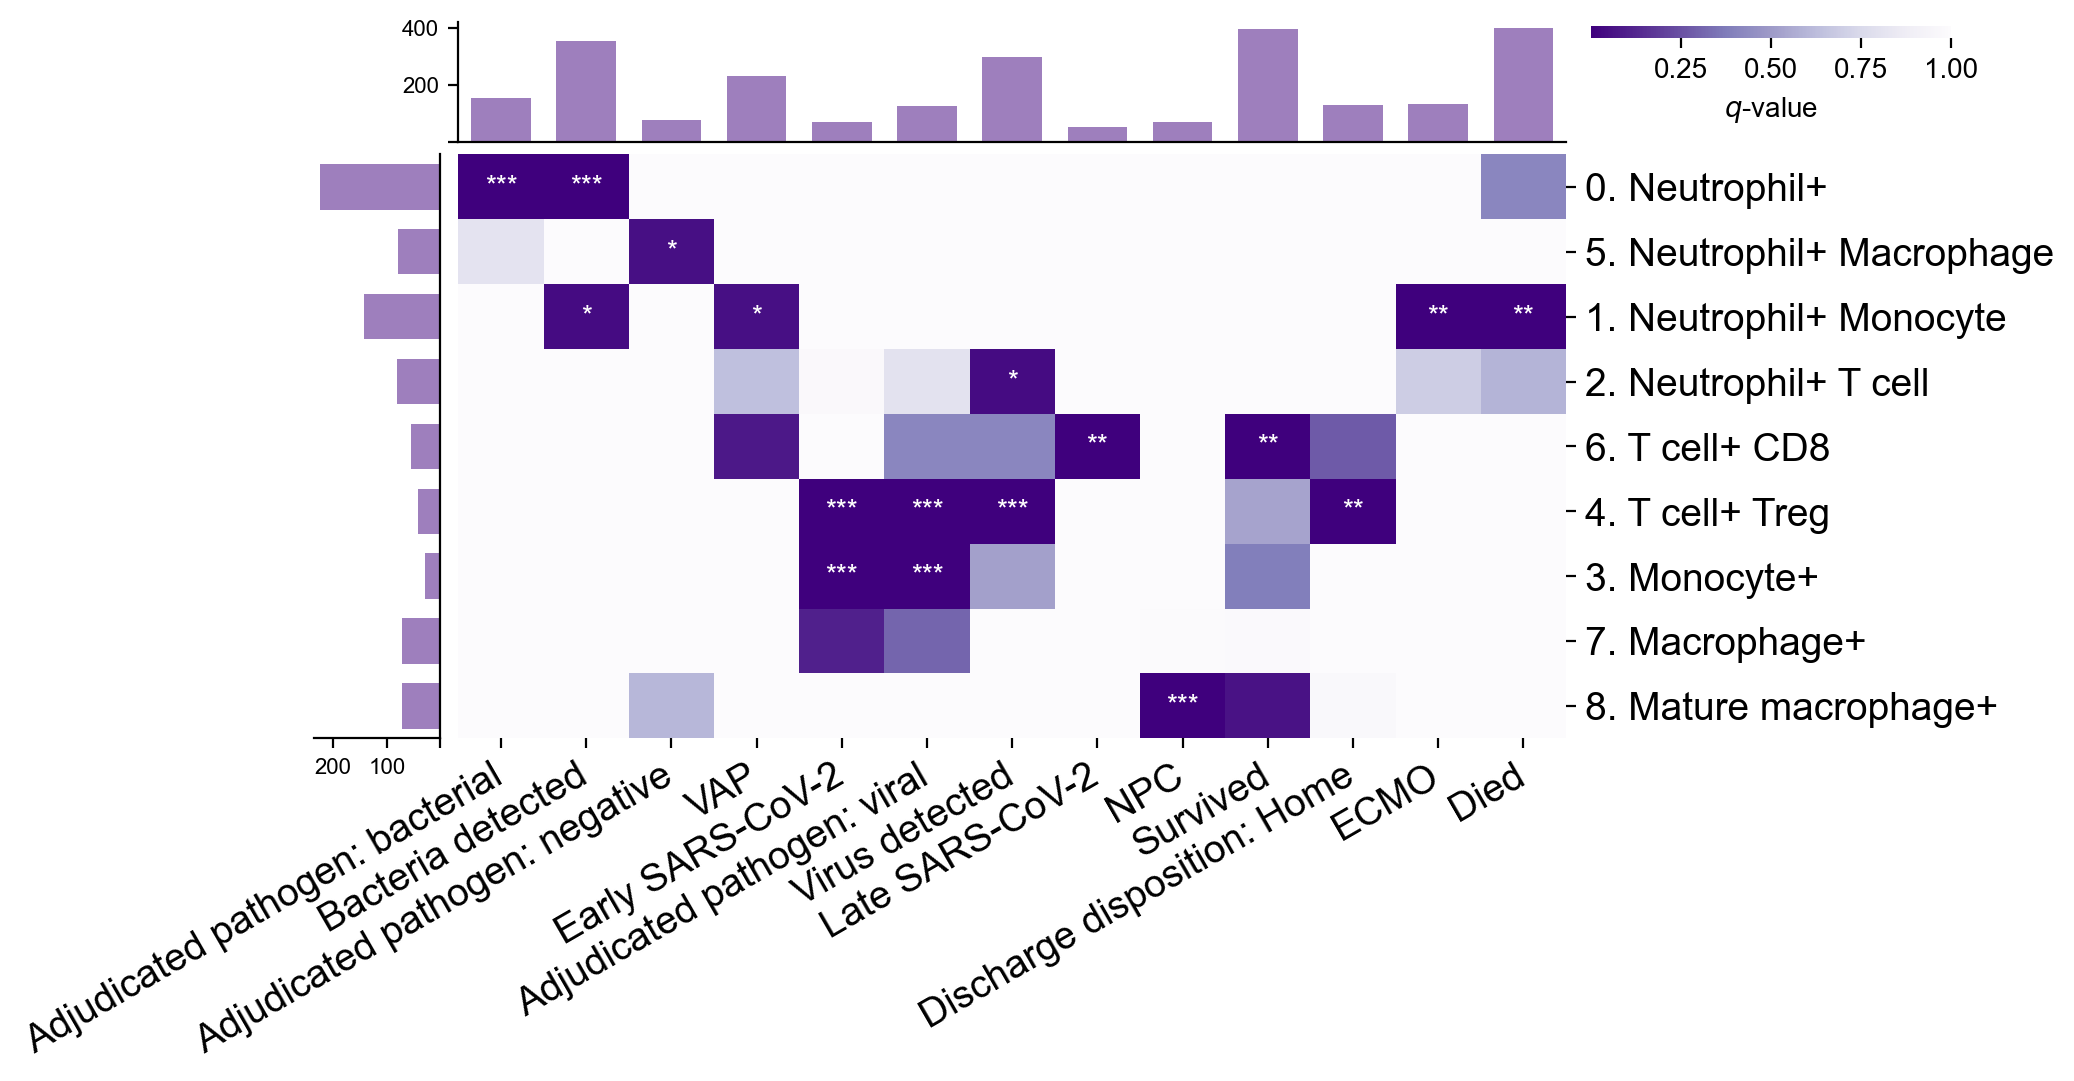

In [54]:
significant_full_qvals_text = significant_full_qvals.copy()
significant_full_qvals_text = significant_full_qvals_text.applymap(get_stars_from_pvalue)

cg = sns.clustermap(
    significant_full_qvals.loc[:, list(to_show.keys())].iloc[cluster_order],
    figsize=(9, 6),
    row_cluster=False,
    col_cluster=False,
    cmap='Purples_r',
    cbar_pos=(0.8, 0.95, 0.2, 0.01),
    annot=significant_full_qvals_text.loc[:, to_show.keys()].iloc[cluster_order],
    fmt='',
    yticklabels=np.array(clustering_sorting_names)[cluster_order],
    xticklabels=list(to_show.values()),
    cbar_kws=dict(
        orientation='horizontal',
        label='$q$-value'
    )
)

# cg.ax_heatmap.set_title(
#     'Hypergeometric FDR q-value for clinical feature enrichment\n'
#     'in Flow cell type abundance based clustering',
#     fontsize=12
# )
cg.ax_col_dendrogram.set_visible(False)
cg.ax_row_dendrogram.set_visible(False)
# cg.ax_heatmap.set_ylabel('Flow cluster')

cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.ax_heatmap.tick_params(labelsize=14)

p = cg.ax_heatmap.get_position()
cg.ax_col_marginal = cg.figure.add_axes([p.x0, p.y1 + 0.01, p.x1 - p.x0, 0.1], sharex=cg.ax_heatmap)
cg.ax_col_marginal.get_xaxis().set_visible(False)

label_fracs = []
for col_name in to_show.keys():
    col, value = col_name.split(': ')
    try:
        value = float(value)
    except:
        pass
    if value == 'True' or value == 'False':
        value = True if value == 'True' else False
    frac = full_df[col].eq(value).sum() # / full_df.shape[0]
    label_fracs.append(frac)

label_fracs = np.array(label_fracs)
cg.ax_col_marginal.bar(
    np.arange(len(to_show)) + 0.5,
    label_fracs,
    width=0.7,
    color=mpl._cm._Purples_data[-1],
    alpha=0.5
)
cg.ax_col_marginal.spines[['top', 'right']].set_visible(False)
cg.ax_col_marginal.tick_params(labelsize=8)#, left=False, labelleft=False, right=True, labelright=True)
cg.ax_col_marginal.set_yticks([0, 200, 400], labels=['', '200', '400'])

cg.ax_row_marginal = cg.figure.add_axes([p.x0 - 0.08, p.y0, 0.07, p.y1 - p.y0], sharey=cg.ax_heatmap)
cg.ax_row_marginal.invert_xaxis()
cg.ax_row_marginal.get_yaxis().set_visible(False)
cg.ax_row_marginal.barh(
    np.arange(full_df.Flow_clusters.nunique()) + 0.5,
    full_df.Flow_clusters.value_counts().sort_index().iloc[cluster_order], # / full_df.shape[0],
    height=0.7,
    color=mpl._cm._Purples_data[-1],
    alpha=0.5
)
cg.ax_row_marginal.spines[['top', 'left']].set_visible(False)
cg.ax_row_marginal.tick_params(labelsize=8)#, left=False, labelleft=False, right=True, labelright=True)
cg.ax_row_marginal.set_xticks([0, 100, 200], labels=['', '100', '200'])

cg.savefig('10I_cluster_categorical_enr_main.pdf')

In [55]:
for k in significant_full_qvals.columns:
    if k not in to_show:
        to_show[k] = k.replace('_', ' ').replace(' flag', '').replace('Ethnicity: ', '').replace('Race: ', '').replace(
            'Global cause failure', 'Overall adjudicated outcome'
        ).replace('Pathogen groups: ', '')

to_show['Pathogen_virus_detected: False'] = 'No virus detected'
to_show['CRRT_flag: 1'] = 'CRRT'
to_show['Smoking_status: Unknown Smoking Status'] = 'Unknown smoking status'
to_show['Tracheostomy_flag: 1'] = 'Tracheostomy'
to_show['ECMO_flag: 0'] = 'No ECMO'
to_show['Episode_category: CAP'] = 'CAP'
to_show['Pathogen_resistance_detected: False'] = 'Pathogen not resistant'
to_show['Hemodialysis_flag: 0'] = 'No hemodialysis'
to_show['Pathogen_fungi_detected: False'] = 'No fungi detected'
to_show['Pathogen_bacteria_detected: False'] = 'No bacteria detected'
to_show['Episode_etiology: Indeterminate'] = 'Adjudicated pathogen: indeterminate'

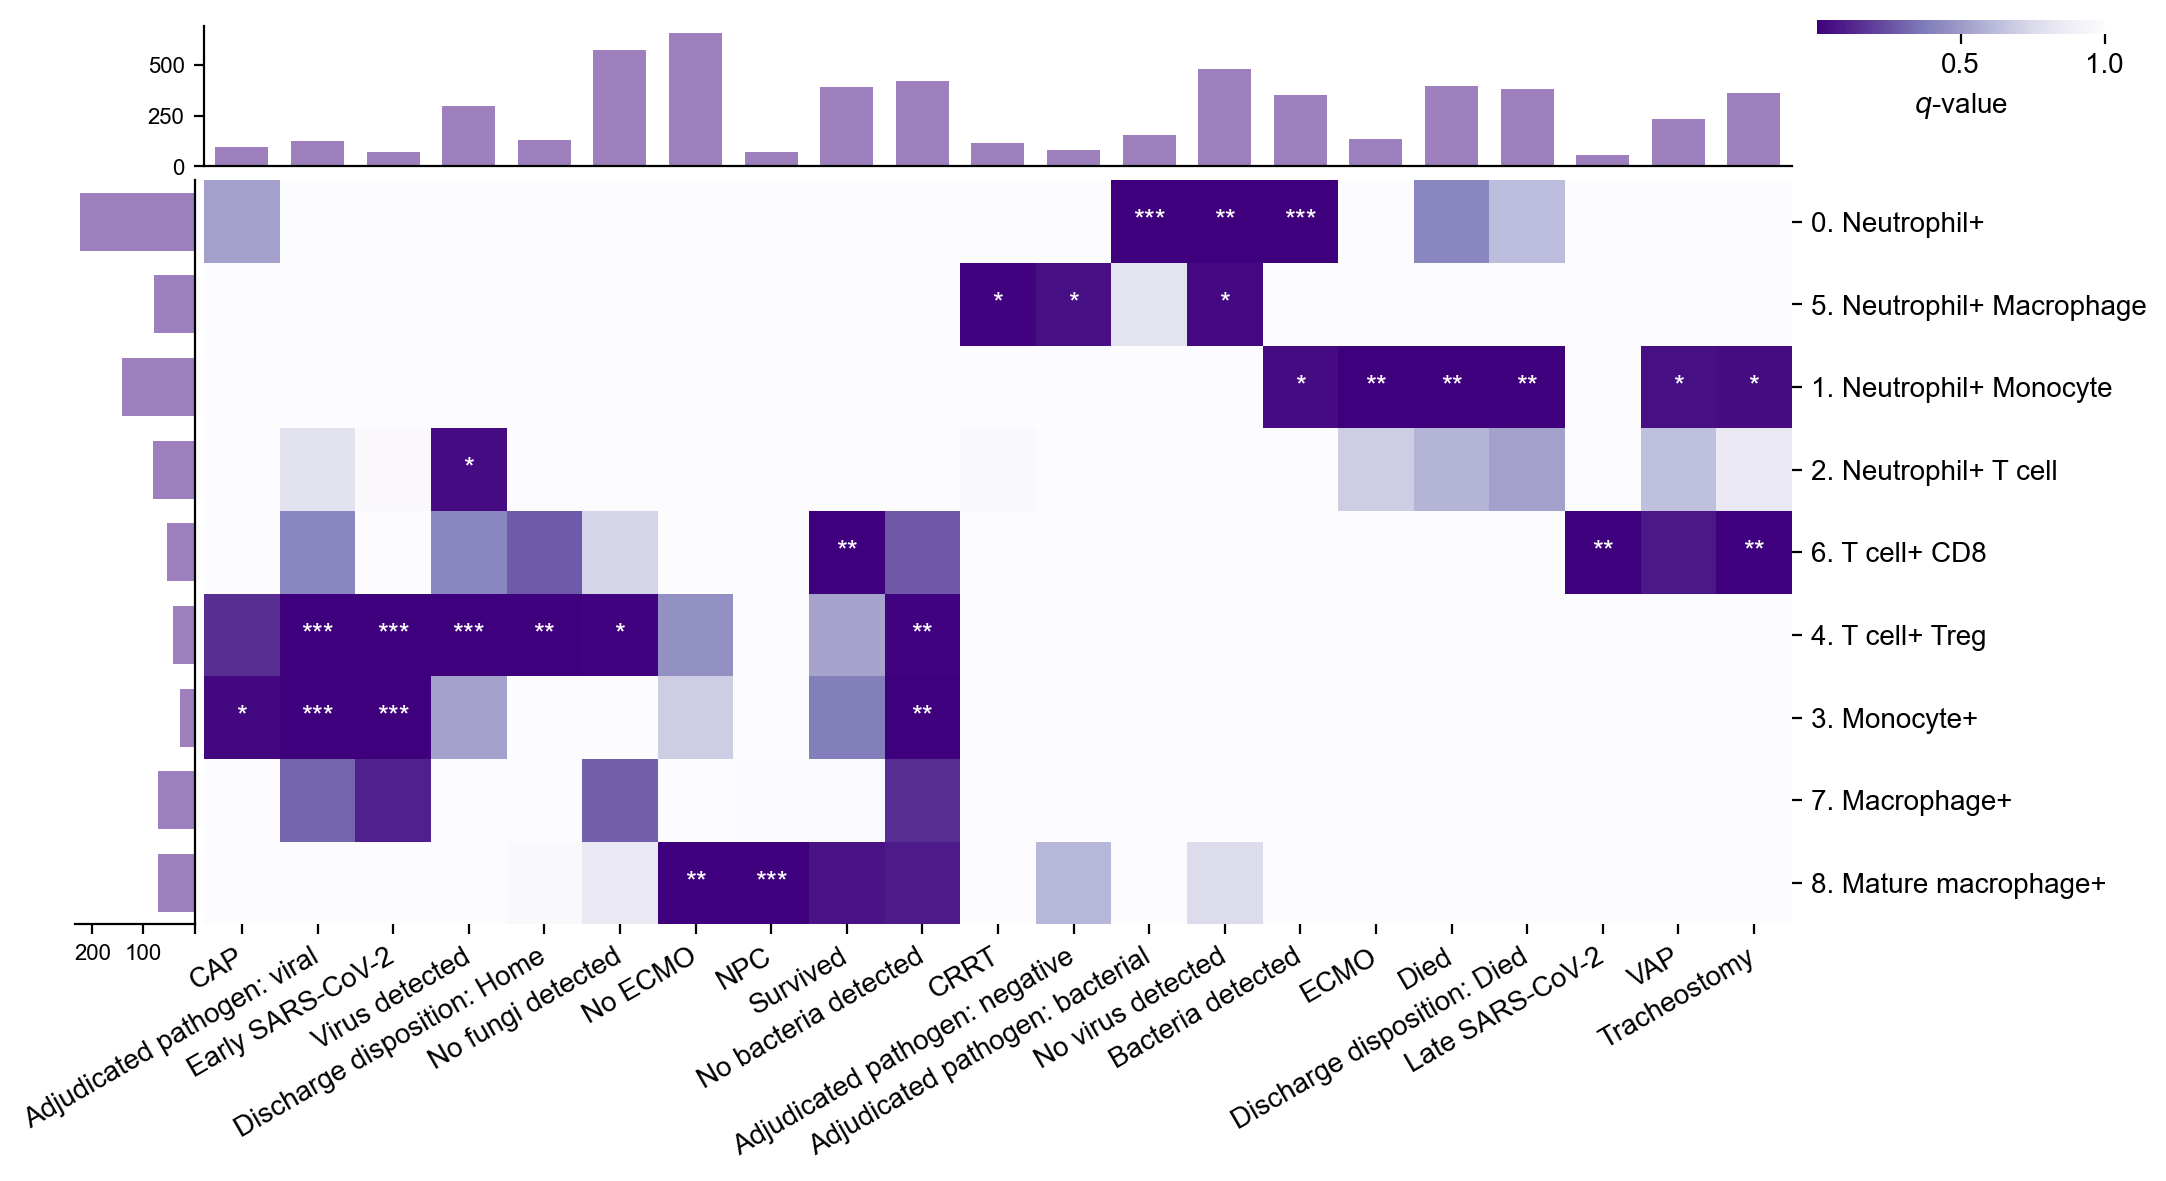

In [56]:
significant_full_qvals_text = significant_full_qvals.copy()
significant_full_qvals_text = significant_full_qvals_text.applymap(get_stars_from_pvalue)

cg = sns.clustermap(
    significant_full_qvals.iloc[cluster_order],
    figsize=(12, 7),
    row_cluster=False,
    cmap='Purples_r',
    cbar_pos=(0.85, 0.95, 0.12, 0.01),
    annot=significant_full_qvals_text.iloc[cluster_order],
    fmt='',
    yticklabels=np.array(clustering_sorting_names)[cluster_order],
    xticklabels=significant_full_qvals.columns.to_series().replace(to_show),
    cbar_kws=dict(
        orientation='horizontal',
        label='$q$-value'
    )
)

# cg.ax_heatmap.set_title(
#     'Hypergeometric FDR q-value for clinical feature enrichment\n'
#     'in Flow cell type abundance based clustering',
#     fontsize=16
# )
cg.ax_col_dendrogram.set_visible(False)
cg.ax_row_dendrogram.set_visible(False)
# cg.ax_heatmap.set_ylabel('Flow cluster')

cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    # fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

p = cg.ax_heatmap.get_position()
cg.ax_col_marginal = cg.figure.add_axes([p.x0, p.y1 + 0.01, p.x1 - p.x0, 0.1], sharex=cg.ax_heatmap)
cg.ax_col_marginal.get_xaxis().set_visible(False)

label_fracs = []
for col_name in significant_full_qvals.columns:
    col, value = col_name.split(': ')
    try:
        value = float(value)
    except:
        pass
    if value == 'True' or value == 'False':
        value = True if value == 'True' else False
    frac = full_df[col].eq(value).sum() # / full_df.shape[0]
    label_fracs.append(frac)

label_fracs = np.array(label_fracs)
cg.ax_col_marginal.bar(
    np.arange(significant_full_qvals.shape[1]) + 0.5,
    label_fracs[cg.dendrogram_col.reordered_ind],
    width=0.7,
    color=mpl._cm._Purples_data[-1],
    alpha=0.5
)
cg.ax_col_marginal.spines[['top', 'right']].set_visible(False)
cg.ax_col_marginal.tick_params(labelsize=8)#, left=False, labelleft=False, right=True, labelright=True)
# cg.ax_col_marginal.set_yticks([0, 0.25, 0.5], labels=['', '25%', '50%'])

cg.ax_row_marginal = cg.figure.add_axes([p.x0 - 0.054, p.y0, 0.05, p.y1 - p.y0], sharey=cg.ax_heatmap)
cg.ax_row_marginal.invert_xaxis()
cg.ax_row_marginal.get_yaxis().set_visible(False)
cg.ax_row_marginal.barh(
    np.arange(full_df.Flow_clusters.nunique()) + 0.5,
    full_df.Flow_clusters.value_counts().sort_index().iloc[cluster_order], # / full_df.shape[0],
    height=0.7,
    color=mpl._cm._Purples_data[-1],
    alpha=0.5
)
cg.ax_row_marginal.spines[['top', 'left']].set_visible(False)
cg.ax_row_marginal.tick_params(labelsize=8)#, left=False, labelleft=False, right=True, labelright=True)
cg.ax_row_marginal.set_xticks([0, 100, 200], labels=['', '100', '200'])

cg.savefig('10I_cluster_categorical_enr.pdf')

In [58]:
def compute_t_test_for_df(
    df,
    column,
    cluster_column='Flow_clusters',
    add_prefix=True,
    filter_nas=True,
    filter_clusters=None,
    min_p_value=1e-5,
    alternative='less',
):
    filter_clusters = filter_clusters if filter_clusters is not None else []
    nb_of_clusters = len(set(df[cluster_column]))
    clusters = [cl_ for cl_ in range(nb_of_clusters) if cl_ not in filter_clusters]
    if filter_nas:
        df = df.copy()
        df = df[np.logical_not(df[column].isna())]
    results = np.zeros((len(clusters), 1))
    for cluster_ind, cluster_nb in enumerate(clusters):
        # print(column, cluster_ind)
        if sum(df[cluster_column] == cluster_nb) == 0:
            print(cluster_column, cluster_nb, column)
            results[cluster_ind] = 1
            continue
        cluster_vals = df[column][df[cluster_column] == cluster_nb]
        outside_cluster_vals = df[column][df[cluster_column] != cluster_nb]
        results[cluster_ind] = scipy.stats.ttest_ind(
            cluster_vals,
            outside_cluster_vals,
            equal_var=False,
            alternative=alternative,
        ).pvalue
    results = np.maximum(results, min_p_value)
    result_df = pd.DataFrame(data=results, columns=[column], index=clusters)
    return result_df

In [59]:
def compute_anova_test_for_df(
    df,
    column,
    cluster_column='Flow_clusters',
    add_prefix=True,
    filter_nas=True,
    filter_clusters=None,
    min_p_value=1e-5,
    alternative='less',
):
    filter_clusters = filter_clusters if filter_clusters is not None else []
    nb_of_clusters = len(set(df[cluster_column]))
    clusters = [cl_ for cl_ in range(nb_of_clusters) if cl_ not in filter_clusters]
    if filter_nas:
        df = df.copy()
        df = df[np.logical_not(df[column].isna())]
    results = np.zeros((len(clusters), 1))
    for cluster_ind, cluster_nb in enumerate(clusters):
        # print(column, cluster_ind)
        if sum(df[cluster_column] == cluster_nb) == 0:
            print(cluster_column, cluster_nb, column)
            results[cluster_ind] = 1
            continue
        cluster_vals = df[column][df[cluster_column] == cluster_nb]
        outside_cluster_vals = df[column][df[cluster_column] != cluster_nb]
        results[cluster_ind] = scipy.stats.f_oneway(
            cluster_vals,
            outside_cluster_vals,
            #equal_var=False,
            #alternative=alternative,
        ).pvalue
    results = np.maximum(results, min_p_value)
    result_df = pd.DataFrame(data=results, columns=[column], index=clusters)
    return result_df

In [60]:
numericals.columns

Index(['Age', 'BMI', 'SOFA_score', 'days_on_ventilator', 'GSC_score',
       'PaO2FIO2_ratio', 'Mean_arterial_pressure', 'Bicarbonate', 'ABG_pH',
       'ABG_PaCO2', 'Urine_output', 'Heart_rate', 'Respiratory_rate',
       'Creatinine', 'Albumin', 'Bilirubin', 'Hemoglobin', 'Platelets',
       'Temperature', 'Driving_pressure', 'Minute_Ventilation', 'Neutrophils',
       'Lymphocytes', 'Procalcitonin_ff', 'Lactic_acid', 'D_dimer_ff',
       'LDH_ff', 'Cumulative_vent_changes', 'BAL_pct_neutrophils',
       'BAL_pct_lymphocytes', 'BAL_amylase', 'Episode_duration',
       'days_of_icu_abx_until_today',
       'cumulative_icu_steroid_dose_until_today', 'sequencing_depth',
       'sequencing_saturation', 'frac_reads_in_cells', 'viability'],
      dtype='object')

This is flow: we don't correlate with scRNAseq features

In [61]:
data_columns = numericals.columns[~numericals.columns.isin([
    'sequencing_depth', 'sequencing_saturation', 'frac_reads_in_cells', 'viability'
])]

In [62]:
nc_all_pvals = [
    compute_t_test_for_df(
        df=full_df,
        column=data_col,
        filter_clusters=[],
        min_p_value=1e-10
    )
    for data_col in data_columns
]

In [63]:
nc_all_anova_pvals = [
    compute_anova_test_for_df(
        df=full_df,
        column=data_col,
        filter_clusters=[],
        min_p_value=1e-10
    )
    for data_col in data_columns
]

In [64]:
full_nc_pvals = pandas.concat(nc_all_pvals, axis=1)

In [65]:
full_nc_anova_pvals = pandas.concat(nc_all_anova_pvals, axis=1)

Apparently this trick is because we use `alternative='less'` in t-test above. So if p-value is > 0.5 it means that values inside our cluster are actually less than outside, and we invert the alternative with `1 - p-value`

Let's quickly test this

In [66]:
TST1 = [5, 21, 22, 3, 2]
TST2 = [1, 2, 3, 4, 5]
scipy.stats.ttest_ind(
    TST1,
    TST2,
    equal_var=False,
    alternative='less',
).pvalue

0.917186868390023

In [67]:
np.allclose(
    scipy.stats.ttest_ind(
        TST2,
        TST1,
        equal_var=False,
        alternative='less',
    ).pvalue,
    1 - scipy.stats.ttest_ind(
        TST1,
        TST2,
        equal_var=False,
        alternative='less',
    ).pvalue
)

True

Ok, I buy this

This rescales p-values from `[0, 0.5]` to `[0, 1]`

In [68]:
full_nc_pvals_ts = pandas.DataFrame(
    2 - 2 * np.maximum(full_nc_pvals.values, 1 - full_nc_pvals.values),
    columns=full_nc_pvals.columns,
    index=full_nc_pvals.index,
)

In [69]:
full_nc_pvals['BAL_pct_neutrophils']

0    1.000000e+00
1    1.000000e+00
2    5.879853e-01
3    1.373159e-03
4    2.040507e-10
5    8.062420e-01
6    1.000000e-10
7    1.145643e-08
8    1.000000e-10
Name: BAL_pct_neutrophils, dtype: float64

In [70]:
full_qvals_nc_ts = apply_fdr_to_df(full_nc_pvals_ts, alpha=0.05)

In [71]:
full_qvals_nc_anova = apply_fdr_to_df(full_nc_anova_pvals, alpha=0.05)

In [72]:
significant_cols_nc = []

for col_name, col_min in full_qvals_nc_ts.min(axis=0).items():
    if col_min < 0.05:
        significant_cols_nc.append(col_name)

In [73]:
significant_cols_anova_nc = []

for col_name, col_min in full_qvals_nc_anova.min(axis=0).items():
    if col_min < 0.05:
        significant_cols_anova_nc.append(col_name)

In [74]:
full_qvals_nc_ts = full_qvals_nc_ts[significant_cols_nc]

In [75]:
full_qvals_nc_anova = full_qvals_nc_anova[significant_cols_anova_nc]

In [76]:
significant_cols_anova_nc

['Age',
 'BMI',
 'days_on_ventilator',
 'PaO2FIO2_ratio',
 'Bicarbonate',
 'ABG_PaCO2',
 'Urine_output',
 'Albumin',
 'Hemoglobin',
 'Platelets',
 'Temperature',
 'Driving_pressure',
 'Minute_Ventilation',
 'Neutrophils',
 'BAL_pct_neutrophils',
 'BAL_pct_lymphocytes',
 'BAL_amylase',
 'days_of_icu_abx_until_today',
 'cumulative_icu_steroid_dose_until_today']

Here we want to get the direction of the initial t-test: p-value > 0.5 with –, p-value < 0.5 with +

In [77]:
colored = (
    np.sign(-2 * full_nc_pvals[significant_cols_nc] + 1)
    * np.log(np.clip(full_qvals_nc_ts, 1e-3, None))
)

In [78]:
text = full_qvals_nc_ts.applymap(get_stars_from_pvalue)
#text[full_qvals_nc_ts.applymap(lambda x: float(x)) > 0.05] = ''

In [85]:
PRETTY_NUM_NAMES = {
    'BAL_pct_lymphocytes': 'BAL lymphocytes (%)',
    'Minute_Ventilation': 'Minute ventilation',
    'BAL_pct_neutrophils': 'BAL neutrophils (%)',
    'cumulative_icu_steroid_dose_until_today': 'ICU steroid dose to date',
    'PaO2FIO2_ratio': r'P$_{\mathrm{a}}$O$_2$/F$_{\mathrm{i}}$O$_2$',
    'days_on_ventilator': 'Days on ventilator',
    'D_dimer_ff': 'D-dimer',
    'LDH_ff': 'LDH',
    'Procalcitonin_ff': 'Procalcitonin',
    'days_of_icu_abx_until_today': 'ICU antibiotic days to date',
    'ABG_PaCO2': r'P$_{\mathrm{a}}$CO$_2$'
}
def pretty_num(name: str) -> str:
    name = PRETTY_NUM_NAMES.get(name, name)
    if '$' in name:
        idx = name.index('$')
        name = name[:idx].replace('_', ' ') + name[idx:]
    else:
        name = name.replace('_', ' ')
    return name

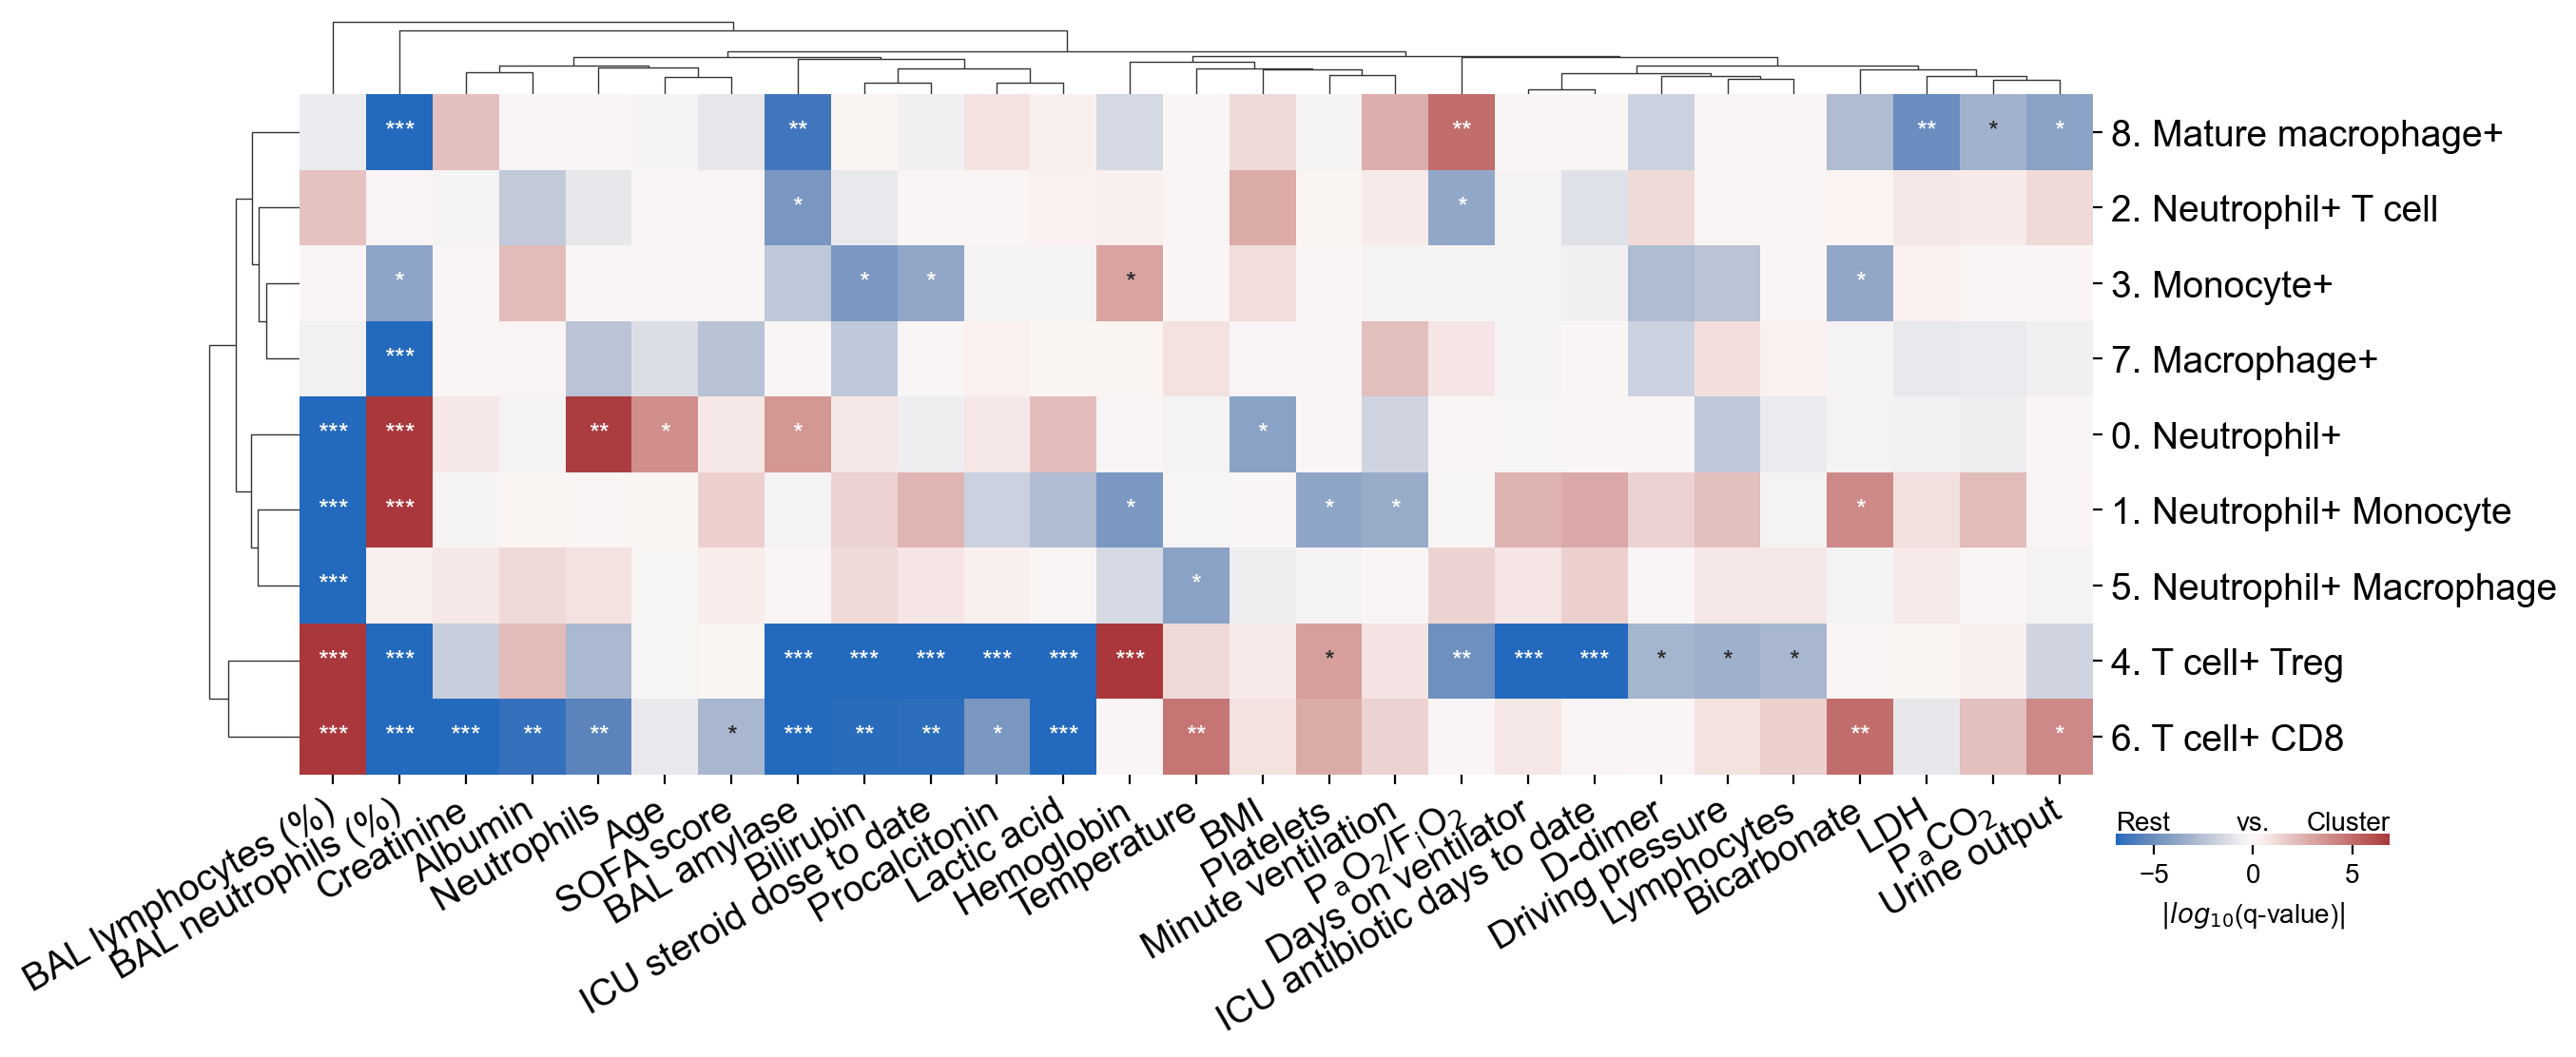

In [93]:
cg = sns.clustermap(
    colored,
    center=0,
    annot=text,
    yticklabels=clustering_sorting_names,
    fmt='',
    cmap='vlag',
    figsize=(12, 6),
    cbar_pos=(0.85, 0.25, 0.12, 0.01),
    cbar_kws=dict(
        orientation='horizontal',
        label='$|log_{10}$(q-value)$|$'
    ),
    dendrogram_ratio=(0.05, 0.1),
    xticklabels=[pretty_num(s) for s in colored.columns]
)
cg.ax_cbar.annotate('Rest', (0, 1.3), xycoords='axes fraction', ha='left')
cg.ax_cbar.annotate('Cluster', (1, 1.3), xycoords='axes fraction', ha='right')
cg.ax_cbar.annotate('vs.', (0.5, 1.3), xycoords='axes fraction', ha='center')
cg.ax_heatmap.set_ylabel('')
cg.ax_heatmap.set_yticklabels(
    cg.ax_heatmap.get_yticklabels(),
    fontsize=14,
)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.savefig('10I_cluster_numerical_assoc.pdf')

Verify

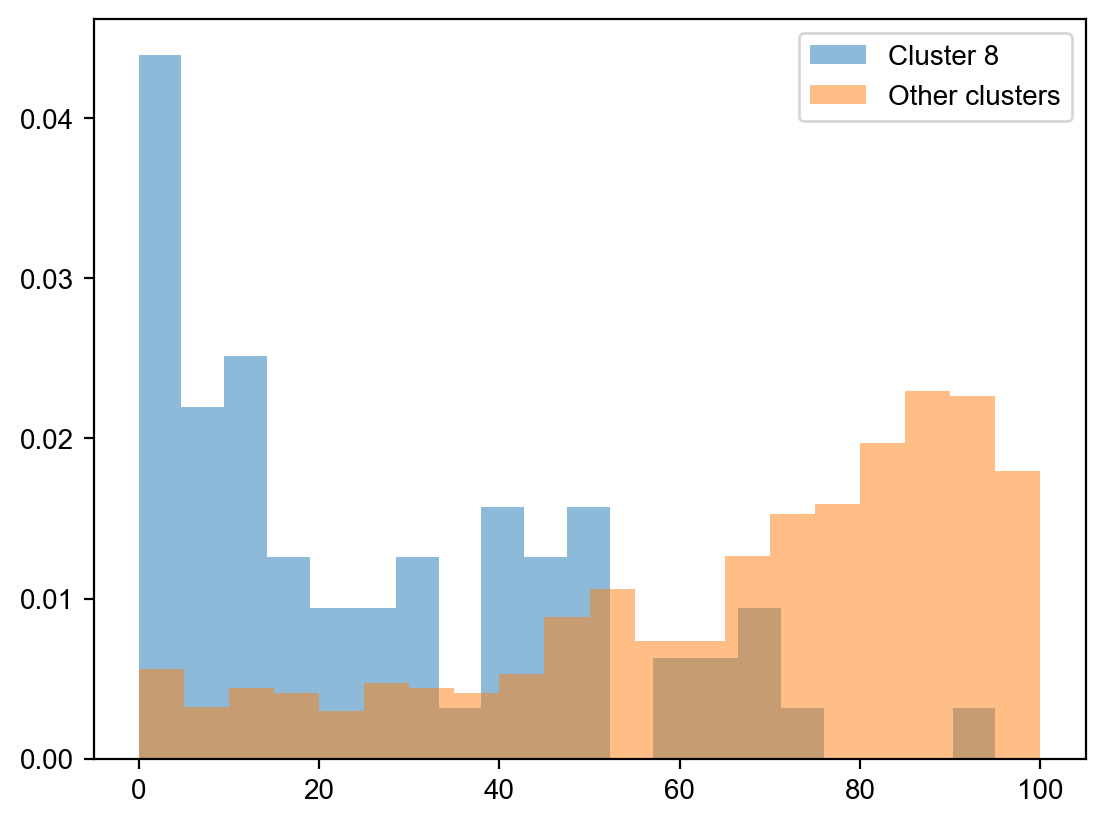

In [94]:
plt.hist(
    full_df['BAL_pct_neutrophils'][full_df['Flow_clusters'] == 8],
    bins=20,
    alpha=0.5,
    density=True,
    label='Cluster 8'
)
plt.hist(
    full_df['BAL_pct_neutrophils'][full_df['Flow_clusters'] != 8],
    bins=20,
    alpha=0.5,
    density=True,
    label='Other clusters'
)
plt.legend();

## Mean cluster profile

In [95]:
avg_cluster_profile_pct = full_df.groupby('Flow_clusters')[cell_columns].mean()
avg_cluster_profile = avg_cluster_profile_pct ** 0.5
avg_cluster_profile[:] = sk_preprocessing.StandardScaler().fit_transform(avg_cluster_profile)

In [96]:
avg_cluster_profile_pct = avg_cluster_profile_pct.applymap(lambda x: f'{x:.1f}%')

In [97]:
cell_type_order = [
    'Neutrophils percent',
    'CD8 T cells percent',
    'CD4 T cells percent',
    'Treg cells percent',
    'Monocytes percent',
    'CD206low macs percent',
    'CD206high macs percent',
]

In [98]:
cell_columns_pretty_names = [
    'Neutrophils',
    'CD8$^{+}$ T cells',
    'CD4$^{+}$ T cells',
    'T$_{\\text{reg}}$ cells',
    'Monocytes',
    'CD206$^{\\text{lo}}$ macrophages',
    'CD206$^{\\text{hi}}$ macrophages',
]

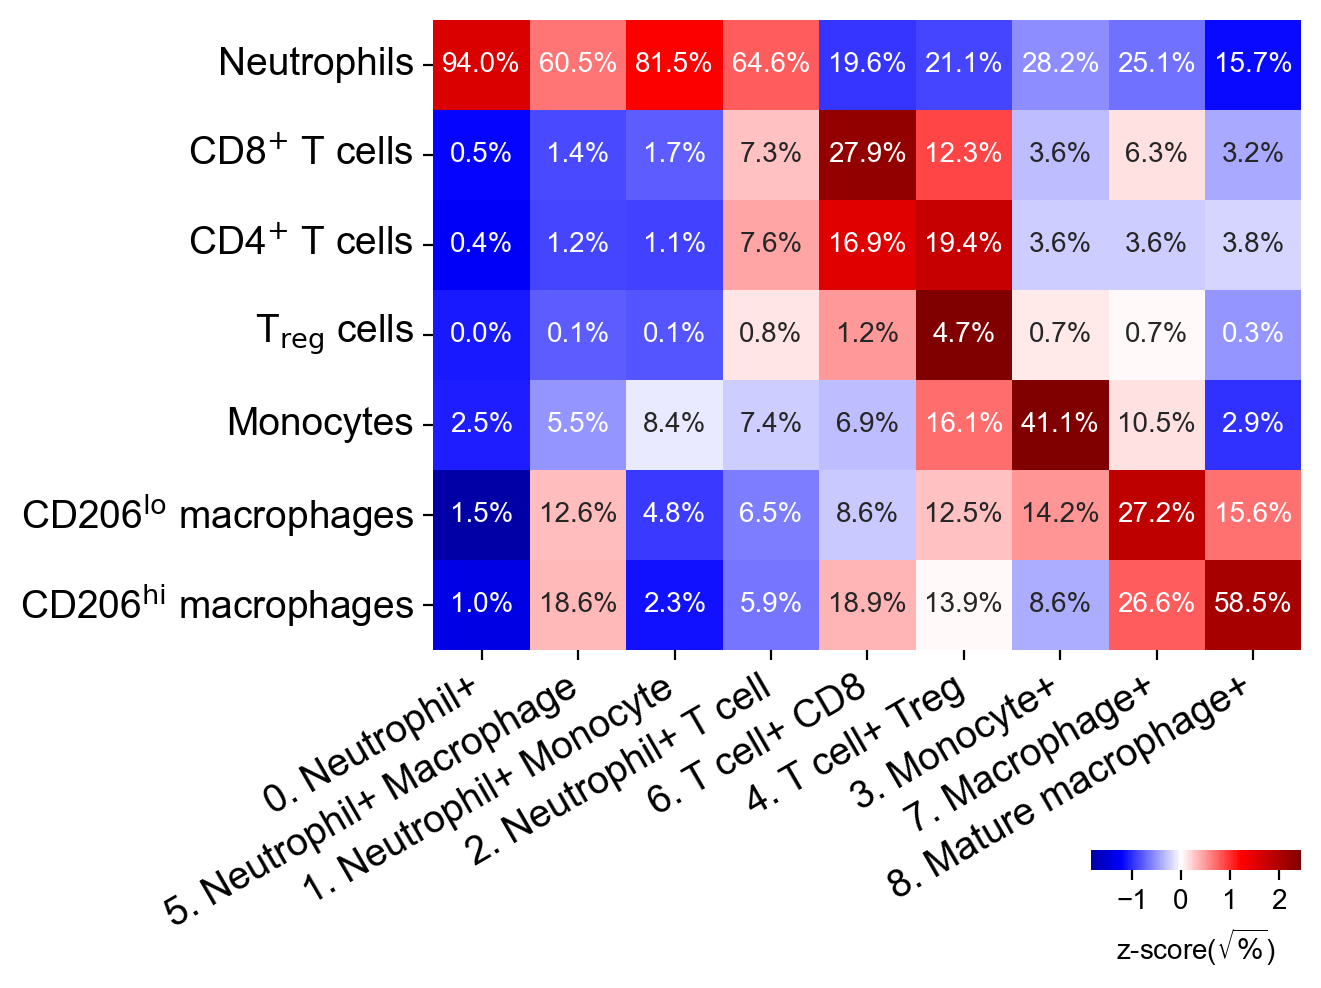

In [100]:
fig, ax = plt.subplots(figsize=(7, 5))

cbar_ax = fig.add_axes((0.83, 0.13, 0.15, 0.02))

sns.heatmap(
    avg_cluster_profile.T.loc[cell_type_order].iloc[:, cluster_order],
    cmap='seismic',
    center=0,
    annot=avg_cluster_profile_pct.T.loc[cell_type_order].iloc[:, cluster_order],
    annot_kws=dict(
        size=10,
    ),
    fmt='',
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label=r'z-score($\sqrt{\%}$)',
        orientation='horizontal',
        ticks=[-1, 0, 1, 2]
    ),
    ax=ax,
    xticklabels=np.array(clustering_sorting_names)[cluster_order],
    yticklabels=cell_columns_pretty_names,
)
ax.tick_params(labelsize=14, labelleft=False, left=False, right=True, labelright=True)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(30)
    t.set_transform(t.get_transform() + trans)
for t in ax.get_yticklabels():
    t.set_rotation(0)

ax.set_xlabel('')
ax.tick_params(labelleft=True, left=True, right=False, labelright=False)
fig.subplots_adjust(top=0.98, bottom=0.35, right=0.98, left=0.36)

fig.savefig('10I_flow_cluster_profile.pdf')